# Explore Data Customer Segmentation

Explore data focus on explore the data through queries, visualizations, and reports to answer business questions and identify patterns relevant to the machine learning goals.

## Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, AutoMinorLocator
from pathlib import Path
from omegaconf import OmegaConf
from olist_ml.config import OlistConfig
from sqlalchemy import create_engine
from sklearn.preprocessing import MinMaxScaler

root_path = project_root=Path.cwd().parent.parent
cfg = OmegaConf.load("../../conf/config.yaml")

raw_data_path = root_path / cfg.paths.raw_data
olist_sqlite_path = raw_data_path / cfg.files.olist_sqlite
db_file = f"sqlite:///{olist_sqlite_path}"
engine = create_engine(db_file)
orders = pd.read_sql("SELECT * FROM orders;", engine)
order_items = pd.read_sql("SELECT * FROM order_items;", engine)
products = pd.read_sql("SELECT * FROM products;", engine)
customers = pd.read_sql("SELECT * FROM customers;", engine)
product_category_name_translation = pd.read_sql("SELECT * FROM product_category_name_translation;", engine)
order_payments = pd.read_sql("SELECT * FROM order_payments;", engine)
order_reviews = pd.read_sql("SELECT * FROM order_reviews;", engine)
sellers = pd.read_sql("SELECT * FROM sellers;", engine)
geolocation = pd.read_sql("SELECT * FROM geolocation;", engine)
leads_closed = pd.read_sql("SELECT * FROM leads_closed;", engine)
leads_qualified = pd.read_sql("SELECT * FROM leads_qualified;", engine)

## Business Questions

1. Do customers place enough orders (≥ 10)?
2.  How concentrated is customer spending?
3.  Do customers show preferences for specific sellers?
4.  Are there distinct purchasing behaviors among customers?


### 1. Do customers place enough orders (≥ 10)?

count    96096.000000
mean         1.034809
std          0.214384
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         17.000000
dtype: float64


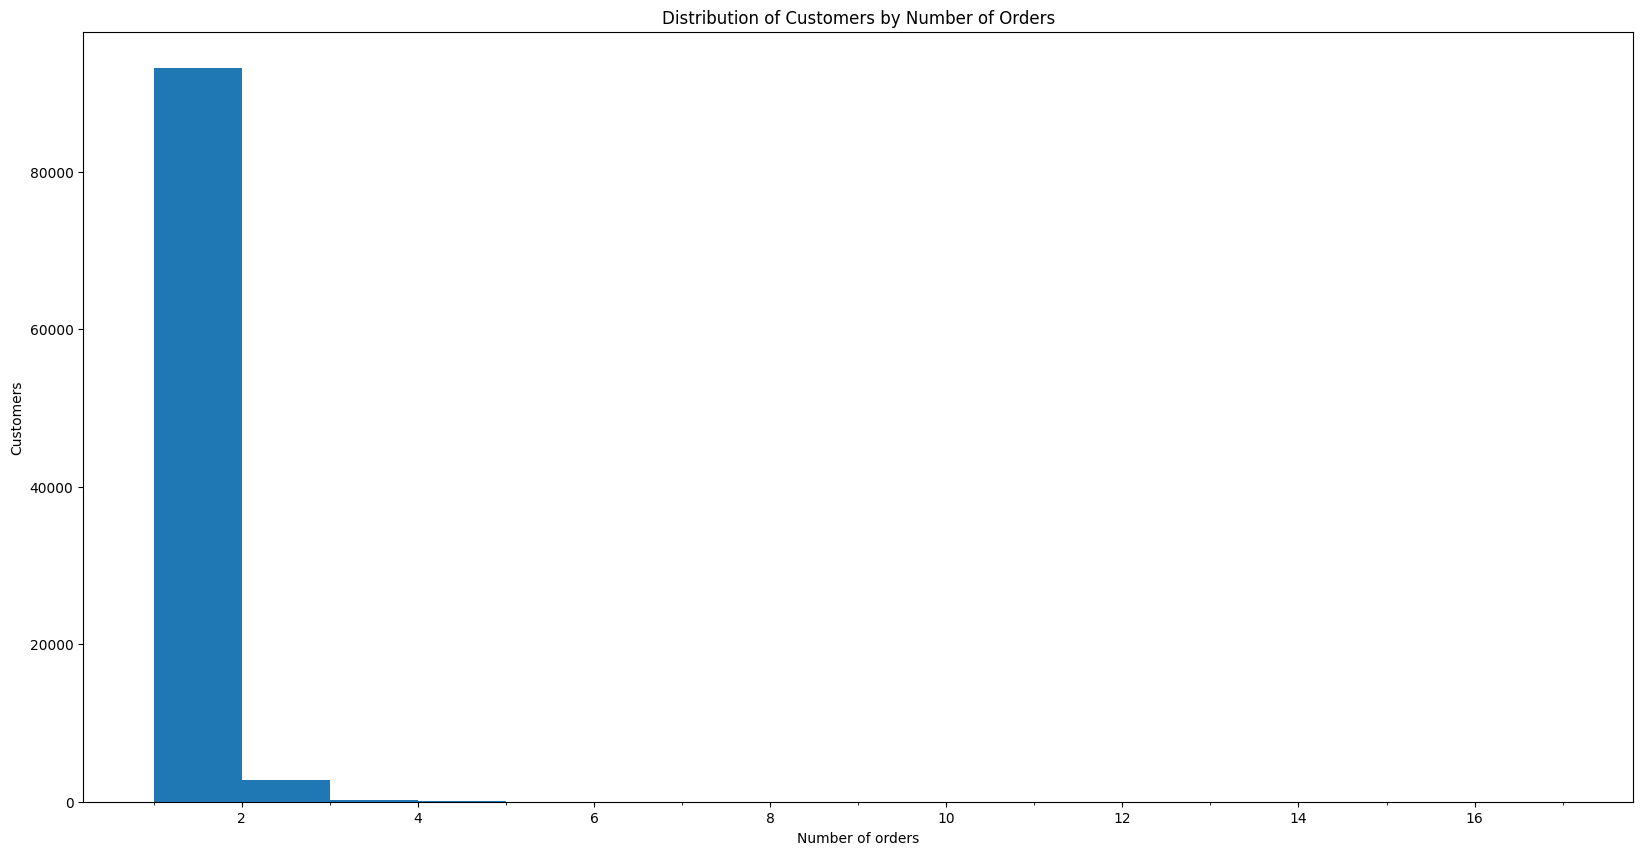

10 or more orders: customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
dtype: int64


In [2]:
orders_merged = pd.merge(
        orders,
        customers,
        how="left",
        on="customer_id"
)
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders_merged[col] = pd.to_datetime(orders_merged[col])

orders_per_customer = (
    orders_merged
    .groupby(["customer_unique_id"])
    .size()
)
print(orders_per_customer.describe())
ax = orders_per_customer.plot.hist(bins=16, figsize=(20, 10))
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.set_title("Distribution of Customers by Number of Orders")
ax.set_ylabel("Customers")
ax.set_xlabel("Number of orders")
plt.savefig("../../docs/images/Distribution of Customers by Number of Orders.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"10 or more orders: "
      f"{orders_per_customer[orders_per_customer >= 10]}")

**Answer:** No. Most customers placed only one order, just 1 customer with ID `8d50f5eadf50201ccdcedfb9e2ac8455` made 17 orders.

## Takeaways

The dataset shows insufficient order history per customer to support reliable customer segmentation. Most customers placed only one order, which limits the ability to model repeat purchasing behavior. Collecting additional order data would be necessary before proceeding with customer-level segmentation.